In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv(
    "../data/raw/SampleSuperstore.csv",
    encoding="latin1"
)

df.columns = df.columns.str.strip()

In [3]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [4]:
df.shape

(9994, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [8]:
df.duplicated().sum()

0

Filling Missing Postal Codes

In [9]:
df["Postal Code"] = (
    df["Postal Code"]
    .fillna(0)
    .astype(int)
)

Converting Dates

In [10]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [11]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int32
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

## Feature Engineering

In [12]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter

## Shipping duration

In [13]:
df["Shipping Days"] = (
    df["Ship Date"] -
    df["Order Date"]
).dt.days

5 Columns added:
Year
Month
Month Name
Quarter
Shipping Days

In [14]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Quarter,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2017,11,November,4,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2017,11,November,4,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2017,6,June,2,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2016,10,October,4,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2016,10,October,4,7


In [15]:
df.to_csv(
    "../data/processed/clean_superstore.csv",
    index=False
)

Creating SQLite database

In [16]:
import sqlite3

conn = sqlite3.connect(
    "../data/processed/superstore.db"
)

df.to_sql(
    "superstore",
    conn,
    if_exists="replace",
    index=False
)

conn.close()

In [17]:
df.shape

(9994, 26)

In [18]:
df["Year"].value_counts().sort_index()

Year
2015    1993
2016    2102
2017    2587
2018    3312
Name: count, dtype: int64

In [19]:
df["Region"].value_counts()

Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

In [20]:
df["Category"].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

## EDA

Total Sales

In [21]:
df["Sales"].sum()

2297200.8603000003

Total Profit

In [50]:
df["Profit"].sum()

286397.0217

Total Orders

In [22]:
df["Order ID"].nunique()

5009

Average Order Value

In [23]:
df["Sales"].sum() / df["Order ID"].nunique()

458.61466566180883

Sales by Category

In [24]:
df.groupby("Category")["Sales"]\
.sum()\
.sort_values(ascending=False)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

Profit by Category

In [25]:
df.groupby("Category")["Profit"]\
.sum()\
.sort_values(ascending=False)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

Average Discount by Category

In [26]:
df.groupby("Category")["Discount"]\
.mean()\
.sort_values(ascending=False)

Category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: Discount, dtype: float64

Sales by Region

In [27]:
df.groupby("Region")["Sales"]\
.sum()\
.sort_values(ascending=False)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

Profit by Region

In [28]:
df.groupby("Region")["Profit"]\
.sum()\
.sort_values(ascending=False)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

Sales by Segment

In [29]:
df.groupby("Segment")["Sales"]\
.sum()\
.sort_values(ascending=False)

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

Profit by Segment

In [30]:
df.groupby("Segment")["Profit"]\
.sum()\
.sort_values(ascending=False)

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64

Shipping Performance

In [31]:
df["Shipping Days"].describe()

count    9994.000000
mean        3.958475
std         1.747603
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

Discount vs Profit Correlation

In [32]:
df[["Discount","Profit"]].corr()

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


Insight: Review aggressive discount strategies, particularly in low-margin categories.

Monthly Sales

In [33]:
monthly_sales = (
    df
    .set_index("Order Date")
    .resample("M")["Sales"]
    .sum()
)

monthly_sales.head()

C:\Users\User\AppData\Local\Temp\ipykernel_12192\3203047573.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["Sales"]


Order Date
2015-01-31    14236.895
2015-02-28     4519.892
2015-03-31    55691.009
2015-04-30    28295.345
2015-05-31    23648.287
Freq: ME, Name: Sales, dtype: float64

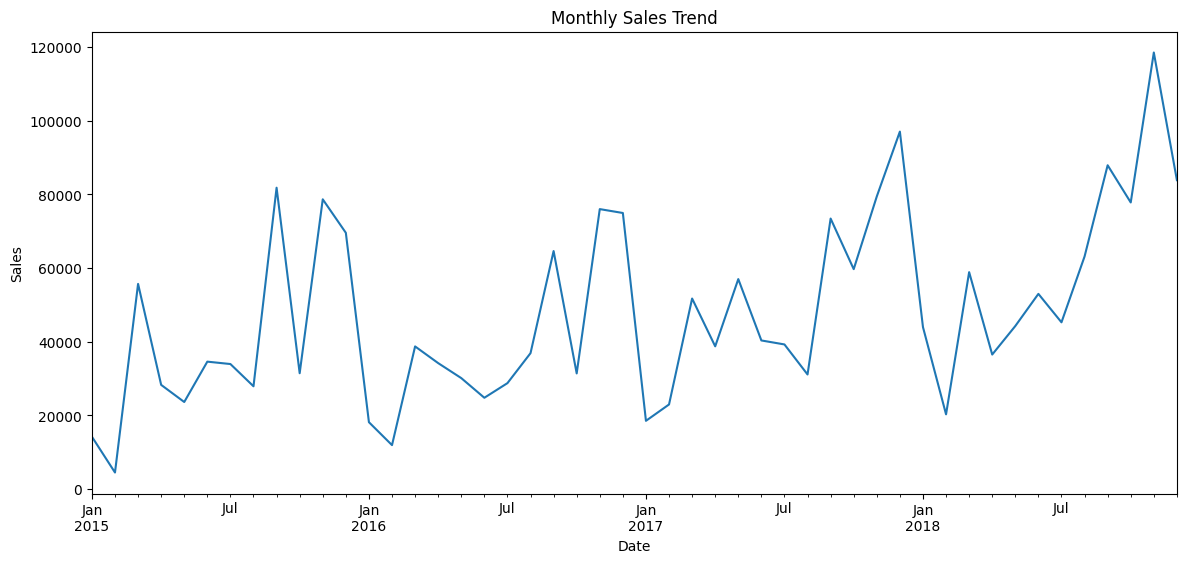

In [34]:
plt.figure(figsize=(14,6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

Creating Rolling Average

In [35]:
rolling_sales = (
    monthly_sales
    .rolling(3)
    .mean()
)

Plot Trend + Rolling Average

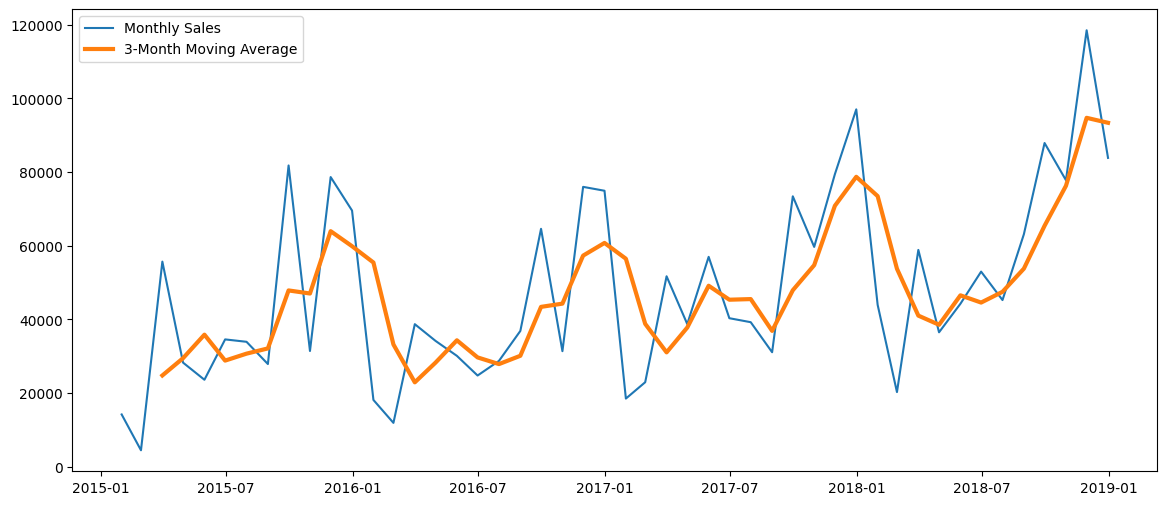

In [36]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales,
    label="Monthly Sales"
)

plt.plot(
    rolling_sales,
    label="3-Month Moving Average",
    linewidth=3
)

plt.legend()
plt.show()

Monthly Profit

In [37]:
monthly_profit = (
    df
    .set_index("Order Date")
    .resample("M")["Profit"]
    .sum()
)

C:\Users\User\AppData\Local\Temp\ipykernel_12192\353651682.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["Profit"]


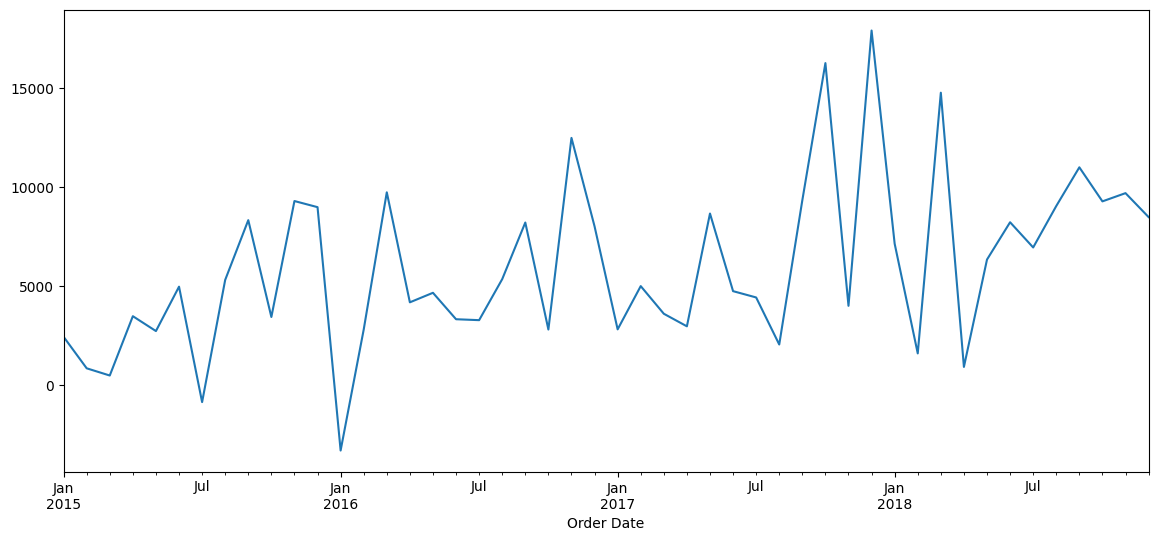

In [38]:
monthly_profit.plot(
    figsize=(14,6)
)
plt.show()

Top 10 Products by Sales

In [39]:
df.groupby("Product Name")["Sales"]\
.sum()\
.sort_values(ascending=False)\
.head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

Top 10 Products by Profit

In [40]:
df.groupby("Product Name")["Profit"]\
.sum()\
.sort_values(ascending=False)\
.head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

Worst 10 Products by Profit

In [41]:
df.groupby("Product Name")["Profit"]\
.sum()\
.sort_values()\
.head(10)

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

Top 10 States by Sales

In [42]:
df.groupby("State")["Sales"]\
.sum()\
.sort_values(ascending=False)\
.head(10)

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

Top 10 States by Profit

In [43]:
df.groupby("State")["Profit"]\
.sum()\
.sort_values(ascending=False)\
.head(10)

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64

Most Unprofitable States

In [44]:
df.groupby("State")["Profit"]\
.sum()\
.sort_values()\
.head(10)

State
Texas            -25729.3563
Ohio             -16971.3766
Pennsylvania     -15559.9603
Illinois         -12607.8870
North Carolina    -7490.9122
Colorado          -6527.8579
Tennessee         -5341.6936
Arizona           -3427.9246
Florida           -3399.3017
Oregon            -1190.4705
Name: Profit, dtype: float64

VISUALIZATIONS

Sales by Category

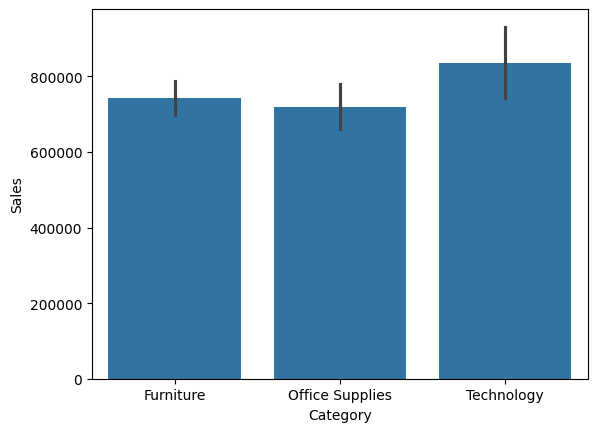

In [45]:
sns.barplot(
    data=df,
    x="Category",
    y="Sales",
    estimator=sum
)

plt.show()

Profit by Category

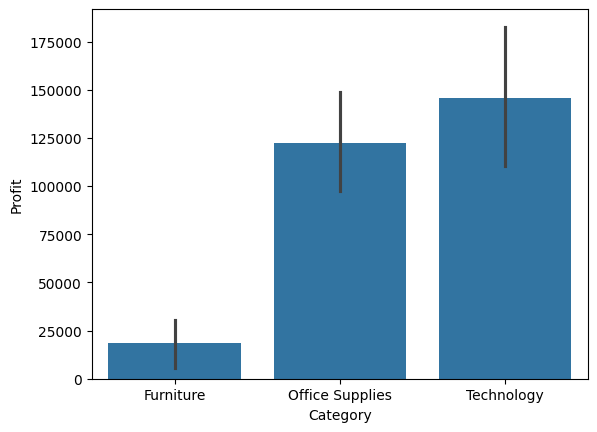

In [46]:
sns.barplot(
    data=df,
    x="Category",
    y="Profit",
    estimator=sum
)

plt.show()

Sales by Region

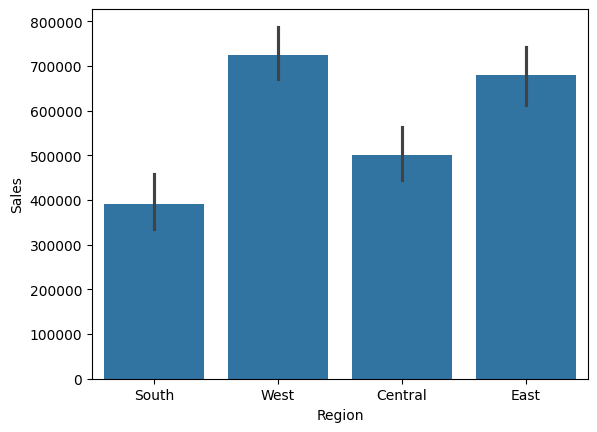

In [47]:
sns.barplot(
    data=df,
    x="Region",
    y="Sales",
    estimator=sum
)

plt.show()

Discount vs Profit

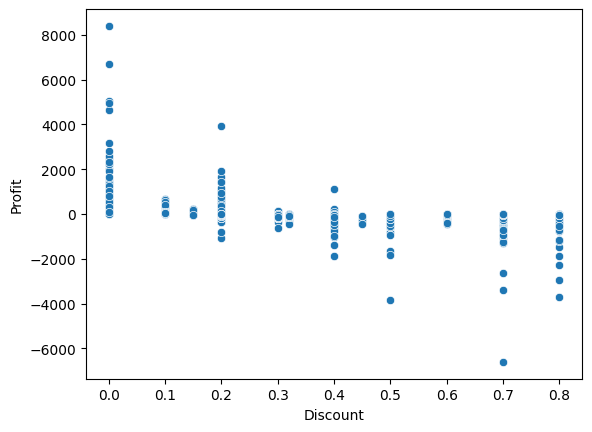

In [48]:
sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit"
)

plt.show()

Sales Distribution

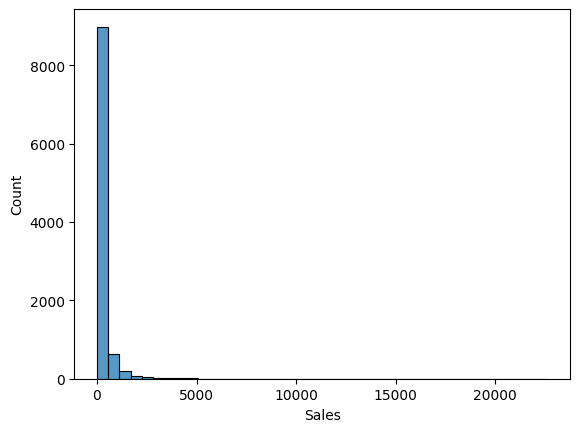

In [49]:
sns.histplot(
    df["Sales"],
    bins=40
)

plt.show()